In [1]:
from IPython.display import display, HTML

display(HTML(r"""
<style>
/* JupyterLab 4.x: center the notebook area */
.jp-NotebookPanel-notebook,
.jp-NotebookPanel .jp-Notebook {
  width: 85% !important;
  max-width: 1100px !important;
  margin: 0 auto !important;
}

/* Make wide outputs scroll instead of breaking the layout */
.jp-OutputArea-output {
  overflow-x: auto !important;
}
</style>
"""))

%config InlineBackend.figure_format = "svg"
print("Centered JupyterLab notebook + SVG inline figures.")

Centered JupyterLab notebook + SVG inline figures.


### Lecture-04: Neural language models

- **CS40008.01, NLP and LLMs**
- **Date:** 03/19/2026
- **Lecturer:** Baojian Zhou
- **Institution:** The School of Data Science, Fudan University

<a id="0"></a> <br>
### Table of Contents
- [1. PyTorch introduction](#1)
  - [1.1 Tensors](#11)
  - [1.2 Operations](#12)
  - [1.3 Torch/Numpy Converting](#13)
  - [1.4 Autograd](#14)
  - [1.5 Gradients](#15)
- [2. micrograd](#2)
  - [2.1 Value](#21)
  - [2.2 Module and Neuron](#22)
  - [2.3 Value/Neuron Operations](#23)
- [3. NPLM](#3)
  - [3.1 Pytorch NPLM](#31)
  - [3.2 NPLM on tiny dataset](#32)
  - [3.3 NPLM on wikitext dataset](#33)
- [4. LSTM](#4)
  - [4.1 Pytorch LSTM](#41)
  - [4.2 Training LSTM](#42)

<a id="1"></a>
### 1. PyTorch introduction

The following tutorial is adopted from:

https://brsoff.github.io/tutorials/beginner/deep_learning_60min_blitz.html

**WHAT IS PYTORCH?**

>It’s a Python-based scientific computing package targeted at two sets of audiences:
> 1. A replacement for NumPy to use the power of GPUs
> 2. a deep learning research platform that provides maximum flexibility and speed

<a id="11"></a>
#### 1.1 Tensors

In [2]:
from __future__ import print_function
import torch
import numpy as np

- Task-01 Construct a 5x3 matrix, uninitialized:

In [3]:
x = torch.empty(5, 4)
print(x)

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])


In [4]:
# Task-02 Construct a randomly initialized matrix:
x = torch.rand(5,4)
print(x)

tensor([[0.9496, 0.5867, 0.4376, 0.6957],
        [0.9117, 0.2463, 0.8895, 0.4935],
        [0.9566, 0.2652, 0.7021, 0.5543],
        [0.9295, 0.6763, 0.8973, 0.8325],
        [0.6193, 0.2337, 0.1567, 0.6683]])


In [5]:
# Task-03 Construct a matrix filled zeros and of dtype long:
x = torch.zeros(5, 4, dtype=torch.long)
print(x)

tensor([[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]])


In [6]:
# Task-04 Construct a tensor directly from data:
x = torch.tensor([5.5, 3, 4., -1.])
print(x)

tensor([ 5.5000,  3.0000,  4.0000, -1.0000])


In [7]:
# Task-05 These methods will reuse properties of the 
# input tensor, e.g. dtype, unless new values are provided by user
x = x.new_ones(5, 4, dtype=torch.double)      # new_* methods take in sizes
print(x)
print(type(x))
x = torch.randn_like(x, dtype=torch.float)    # override dtype!
print(x)
print(type(x))

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]], dtype=torch.float64)
<class 'torch.Tensor'>
tensor([[-0.1201,  0.3882,  1.9301, -0.1750],
        [-0.5896,  1.2316,  0.9700, -0.1973],
        [-1.3624, -0.4265,  0.7903,  2.2594],
        [ 1.5731, -0.2011, -0.3799,  1.6282],
        [ 0.9733, -0.4441, -0.2818, -0.9617]])
<class 'torch.Tensor'>


<a id="12"></a>
#### 1.2 Operations

In [8]:
# Task-06 Get its size:
print(x.size())

torch.Size([5, 4])


In [9]:
# Task-07 Addition using +
y = torch.rand(5, 4)
print(x + y)

tensor([[ 0.5896,  1.3562,  2.3443,  0.3792],
        [-0.2818,  1.7616,  1.1249, -0.0989],
        [-1.3507,  0.5599,  1.5890,  2.5569],
        [ 2.3700,  0.6926, -0.3614,  2.4728],
        [ 1.8870,  0.2736,  0.0317, -0.4578]])


In [10]:
# Task-08 Addition using add() method
print(torch.add(x, y))

tensor([[ 0.5896,  1.3562,  2.3443,  0.3792],
        [-0.2818,  1.7616,  1.1249, -0.0989],
        [-1.3507,  0.5599,  1.5890,  2.5569],
        [ 2.3700,  0.6926, -0.3614,  2.4728],
        [ 1.8870,  0.2736,  0.0317, -0.4578]])


In [11]:
# Task-09 Addition: providing an output tensor as argument
result = torch.empty(5, 4)
torch.add(x, y, out=result)
print(result)

tensor([[ 0.5896,  1.3562,  2.3443,  0.3792],
        [-0.2818,  1.7616,  1.1249, -0.0989],
        [-1.3507,  0.5599,  1.5890,  2.5569],
        [ 2.3700,  0.6926, -0.3614,  2.4728],
        [ 1.8870,  0.2736,  0.0317, -0.4578]])


In [12]:
# Task-10 Addition: in-place
# Any operation that mutates a tensor in-place is post-fixed with an _. 
# For example: x.copy_(y), x.t_(), will change x.
# adds x to y
y.add_(x)
print(y)

tensor([[ 0.5896,  1.3562,  2.3443,  0.3792],
        [-0.2818,  1.7616,  1.1249, -0.0989],
        [-1.3507,  0.5599,  1.5890,  2.5569],
        [ 2.3700,  0.6926, -0.3614,  2.4728],
        [ 1.8870,  0.2736,  0.0317, -0.4578]])


In [13]:
# Task-11 You can use standard NumPy-like indexing with all bells and whistles!
print(x[:, 1])

tensor([ 0.3882,  1.2316, -0.4265, -0.2011, -0.4441])


In [14]:
# Task-12 Resizing: If you want to resize/reshape tensor, you can use torch.view
x = torch.randn(4, 4)
y = x.view(16)
z = x.view(-1, 8)  # the size -1 is inferred from other dimensions
print(x.size(), y.size(), z.size())

torch.Size([4, 4]) torch.Size([16]) torch.Size([2, 8])


In [15]:
# Task-13 Get numerical value: 
# If you have a one element tensor, use .item() 
# to get the value as a Python number
x = torch.randn(1)
print(x)
print(x.item())
print(y[0].item())

tensor([-0.4632])
-0.4632163345813751
-1.031019926071167


<a id="13"></a>
#### 1.3 Torch/Numpy Converting

In [16]:
# Task-14 Converting a Torch Tensor to a NumpPy Array
a = torch.ones(5)
print(a)
b = a.numpy()
print(b)

tensor([1., 1., 1., 1., 1.])
[1. 1. 1. 1. 1.]


In [17]:
# Task-15 See how the numpy array changed in value.
a.add_(1)
print(a)
print(b)
# They share the same memory

tensor([2., 2., 2., 2., 2.])
[2. 2. 2. 2. 2.]


In [18]:
# Task-16 Converting NumPy Array to Torch Tensor
a = np.ones(5)
b = torch.from_numpy(a)
np.add(a, 1, out=a)
print(a)
print(b)

[2. 2. 2. 2. 2.]
tensor([2., 2., 2., 2., 2.], dtype=torch.float64)


In [20]:
# Task-17 Tensors can be moved onto any device using the .to method.
# let us run this cell only if CUDA is available
# We will use ``torch.device`` objects to move tensors in and out of GPU
if torch.cuda.is_available():
    device = torch.device("cuda")          # a CUDA device object
    y = torch.ones_like(x, device=device)  # directly create a tensor on GPU
    x = x.to(device)                       # or just use strings ``.to("cuda")``
    z = x + y
    print(z)
    print(z.to("cpu", torch.double))       # ``.to`` can also change dtype together!

In [22]:
x = torch.randn(2, 2)
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
print("device =", device)

x = x.to(device)
y = torch.ones_like(x)
z = x + y
print(z)
print(z.to("cpu", torch.float))

device = mps
tensor([[ 0.7973,  0.6475],
        [-0.0454,  1.4162]], device='mps:0')
tensor([[ 0.7973,  0.6475],
        [-0.0454,  1.4162]])


<a id="14"></a>
#### 1.4 Autograd

- Central to all neural networks in PyTorch is the *autograd* package. Let’s first briefly visit this, and we will then go to training our first neural network.
- The autograd package provides automatic differentiation for all operations on Tensors. It is a define-by-run framework, which means that your backprop is defined by how your code is run, and that every single iteration can be different.

In [23]:
# Task-18 Create a tensor and set requires_grad=True to track computation with it
x = torch.ones(2, 2, requires_grad=True)
print(x)
y = x + 2
print(y)
print(y.grad_fn)

tensor([[1., 1.],
        [1., 1.]], requires_grad=True)
tensor([[3., 3.],
        [3., 3.]], grad_fn=<AddBackward0>)


In [24]:
# Task-19 do operations on y

z = y * y * 3
out = z.mean()
print(z, out)

a = torch.randn(2, 2)
a = ((a * 3) / (a - 1))
print(a.requires_grad)
a.requires_grad_(True)
print(a.requires_grad)
b = (a * a).sum()
print(b.grad_fn)

tensor([[27., 27.],
        [27., 27.]], grad_fn=<MulBackward0>) tensor(27., grad_fn=<MeanBackward0>)
False
True


<a id=15></a>
#### 1.5 Gradients

- Let’s backprop now Because out contains a single scalar,  out.backward() is equivalent to out.backward(torch.tensor(1)).

In [25]:
# Task-20 do the backprop
out.backward()
print(x.grad)

tensor([[4.5000, 4.5000],
        [4.5000, 4.5000]])


In [26]:
# Task-21 the autograd operation could complicated

x = torch.randn(3, requires_grad=True)
y = x * 2
while y.data.norm() < 1000:
    y = y * 2
print(y)
gradients = torch.tensor([0.1, 1.0, 0.0001], dtype=torch.float)
y.backward(gradients)
print(x.grad)

tensor([   46.9762, -1780.8768,   -30.0420], grad_fn=<MulBackward0>)
tensor([1.0240e+02, 1.0240e+03, 1.0240e-01])


In [27]:
# Task-22 Use requires_grad()
# You can also stop autograd from tracking history on Tensors with 
# .requires_grad=True by wrapping the code block in with torch.no_grad():
print(x.requires_grad)
print((x ** 2).requires_grad)
with torch.no_grad():
    print((x ** 2).requires_grad)

True
True
False


In [28]:
# Task-23 create a neural network model

# A typical training procedure for a neural network is as follows:

# Define the neural network that has some learnable parameters (or weights)
# Iterate over a dataset of inputs
# Process input through the network
# Compute the loss (how far is the output from being correct)
# Propagate gradients back into the network’s parameters
# Update the weights of the network, typically using a simple update rule: 
# weight = weight - learning_rate * gradient

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class Net(nn.Module):

    def __init__(self):
        super(Net, self).__init__()
        # 1 input image channel, 6 output channels, 5x5 square convolution
        # kernel
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        # an affine operation: y = Wx + b
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # Max pooling over a (2, 2) window
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        # If the size is a square you can only specify a single number
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(-1, self.num_flat_features(x))
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def num_flat_features(self, x):
        size = x.size()[1:]  # all dimensions except the batch dimension
        num_features = 1
        for s in size:
            num_features *= s
        return num_features


net = Net()
print(net)

Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=256, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


- **You can install torchinfo via ```conda install -c conda-forge torchinfo```**

In [29]:
from torchinfo import summary

model = Net()
summary(model, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [1, 10]                   --
├─Conv2d: 1-1                            [1, 6, 24, 24]            156
├─Conv2d: 1-2                            [1, 16, 8, 8]             2,416
├─Linear: 1-3                            [1, 120]                  30,840
├─Linear: 1-4                            [1, 84]                   10,164
├─Linear: 1-5                            [1, 10]                   850
Total params: 44,426
Trainable params: 44,426
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.29
Input size (MB): 0.00
Forward/backward pass size (MB): 0.04
Params size (MB): 0.18
Estimated Total Size (MB): 0.22

In [30]:
# Task-24 The learnable parameters of a model are returned by net.parameters()
params = list(net.parameters())
print(len(params))
print(params[0].size())  # conv1's .weight

10
torch.Size([6, 1, 5, 5])


In [31]:
# Task-25 
input = torch.randn(1, 1, 28, 28)
out = net(input)
print(out)

tensor([[ 0.0736, -0.0152, -0.1607, -0.1505, -0.1309, -0.0190,  0.1121,  0.1333,
          0.0833,  0.0118]], grad_fn=<AddmmBackward0>)


In [32]:
# Task-26 Zero the gradient buffers of all parameters and backprops with random gradients:
net.zero_grad()
out.backward(torch.randn(1, 10))

In [33]:
# Task-27 Loss function 

output = net(input)
target = torch.randn(10)  # a dummy target, for example
target = target.view(1, -1)  # make it the same shape as output
criterion = nn.MSELoss()

loss = criterion(output, target)
print(loss)

print(loss.grad_fn)  # MSELoss
print(loss.grad_fn.next_functions[0][0])  # Linear
print(loss.grad_fn.next_functions[0][0].next_functions[0][0])  # ReLU


tensor(1.1086, grad_fn=<MseLossBackward0>)


In [34]:
# Task-28 Backprop
net.zero_grad()     # zeroes the gradient buffers of all parameters
print('conv1.bias.grad before backward')
print(net.conv1.bias.grad)
loss.backward()
print('conv1.bias.grad after backward')
print(net.conv1.bias.grad)
# Update the weights

learning_rate = 0.01
for f in net.parameters():
    f.data.sub_(f.grad.data * learning_rate)

# create your optimizer
optimizer = optim.Adam(net.parameters(), lr=0.001)

# in your training loop:
optimizer.zero_grad()   # zero the gradient buffers
output = net(input)
loss = criterion(output, target)
loss.backward()
optimizer.step()    # Does the update

conv1.bias.grad before backward
None
conv1.bias.grad after backward
tensor([ 0.0021, -0.0139, -0.0080, -0.0183, -0.0012,  0.0076])


In [35]:
x = torch.tensor(-2.0, requires_grad=True)
y = torch.tensor(5.0, requires_grad=True)
z = torch.tensor(-4.0, requires_grad=True)
f = (x+y)*z # Define the computation graph
f.backward() # PyTorch’s internal backward gradient computation
print('Gradients after backpropagation:', x.grad, y.grad, z.grad)

Gradients after backpropagation: tensor(-4.) tensor(-4.) tensor(3.)


<a id=2></a>
### 2. micrograd package

- Please try it at [micrograd](https://github.com/karpathy/micrograd).

<a id=21></a>
#### 2.1 Value

In [36]:
class Value:
    """ stores a single scalar value and its gradient """

    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0
        # internal variables used for autograd graph construction
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op # the op that produced this node, for graphviz / debugging / etc

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out

    def backward(self):

        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # go one variable at a time and apply the chain rule to get its gradient
        self.grad = 1
        for v in reversed(topo):
            v._backward()

    def __neg__(self): # -self
        return self * -1

    def __radd__(self, other): # other + self
        return self + other

    def __sub__(self, other): # self - other
        return self + (-other)

    def __rsub__(self, other): # other - self
        return other + (-self)

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"


<a id=22></a>
#### 2.2 Module and Neuron

In [41]:
import random

class Module:

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0

    def parameters(self):
        return []

class Neuron(Module):

    def __init__(self, nin, nonlin=True):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(0)
        self.nonlin = nonlin

    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        return act.relu() if self.nonlin else act

    def parameters(self):
        return self.w + [self.b]

    def __repr__(self):
        return f"{'ReLU' if self.nonlin else 'Linear'}Neuron({len(self.w)})"

class Layer(Module):

    def __init__(self, nin, nout, **kwargs):
        self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"

class MLP(Module):

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1], nonlin=i!=len(nouts)-1) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"


<a id=23></a>

#### 2.3 Value/Neuron operations

In [42]:
import torch

def test_sanity_check():

    x = Value(-4.0)
    z = 2 * x + 2 + x
    q = z.relu() + z * x
    h = (z * z).relu()
    y = h + q + q * x
    y.backward()
    xmg, ymg = x, y

    x = torch.Tensor([-4.0]).double()
    x.requires_grad = True
    z = 2 * x + 2 + x
    q = z.relu() + z * x
    h = (z * z).relu()
    y = h + q + q * x
    y.backward()
    xpt, ypt = x, y

    # forward pass went well
    assert ymg.data == ypt.data.item()
    # backward pass went well
    assert xmg.grad == xpt.grad.item()

def test_more_ops():

    a = Value(-4.0)
    b = Value(2.0)
    c = a + b
    d = a * b + b**3
    c += c + 1
    c += 1 + c + (-a)
    d += d * 2 + (b + a).relu()
    d += 3 * d + (b - a).relu()
    e = c - d
    f = e**2
    g = f / 2.0
    g += 10.0 / f
    g.backward()
    amg, bmg, gmg = a, b, g

    a = torch.Tensor([-4.0]).double()
    b = torch.Tensor([2.0]).double()
    a.requires_grad = True
    b.requires_grad = True
    c = a + b
    d = a * b + b**3
    c = c + c + 1
    c = c + 1 + c + (-a)
    d = d + d * 2 + (b + a).relu()
    d = d + 3 * d + (b - a).relu()
    e = c - d
    f = e**2
    g = f / 2.0
    g = g + 10.0 / f
    g.backward()
    apt, bpt, gpt = a, b, g

    tol = 1e-6
    # forward pass went well
    assert abs(gmg.data - gpt.data.item()) < tol
    # backward pass went well
    assert abs(amg.grad - apt.grad.item()) < tol
    assert abs(bmg.grad - bpt.grad.item()) < tol

In [43]:
test_sanity_check()
test_more_ops()

In [44]:
a = Value(-4.0)
b = Value(2.0)
c = a + b
d = a * b + b**3
c += c + 1
c += 1 + c + (-a)
d += d * 2 + (b + a).relu()
d += 3 * d + (b - a).relu()
e = c - d
f = e**2
g = f / 2.0
g += 10.0 / f
print(f'{g.data:.4f}') # prints 24.7041, the outcome of this forward pass
g.backward()
print(f'{a.grad:.4f}') # prints 138.8338, i.e. the numerical value of dg/da
print(f'{b.grad:.4f}') # prints 645.5773, i.e. the numerical value of dg/db

24.7041
138.8338
645.5773


<a id=3></a>
### 3. NPLM

- Please check the [NPLM paper](https://baojian.github.io/llm-26/papers/lecture-04-readings-1-NPLM.pdf).

NPLM computes the following function, with a *softmax* output layer, which guarantees positive probabilities summing to 1 :

$$
\hat{P}\left(w_t \mid w_{t-n+1:t-1}\right)=\frac{e^{y_{w_t}}}{\sum_i e^{y_i}} .
$$

The $y_i$ are the unnormalized log-probabilities for each output word $i$, computed as follows, with parameters $b, W, U, d$ and $H$ :

$$
y=b+W x+U \tanh (d+H x)
$$

where the hyperbolic tangent tanh is applied element by element, $W$ is optionally zero (no direct connections), and $x$ is the word features layer activation vector, which is the concatenation of the input word features from the matrix C :

$$
x=\left(C\left(w_{t-1}\right), C\left(w_{t-2}\right), \cdots, C\left(w_{t-n+1}\right)\right) .
$$


Let $h$ be the number of hidden units, and $m$ the number of features associated with each word. When no direct connections from word features to outputs are desired, the matrix $W$ is set to 0 . The free parameters of the model are the output biases $b$ (with $|V|$ elements), the hidden layer biases $d$ (with $h$ elements), the hidden-to-output weights $U$ (a $|V| \times h$ matrix), the word features to output weights $W$ (a $|V| \times(n-1) m$ matrix), the hidden layer weights $H$ (a $h \times(n-1) m$ matrix), and the word features $C$ (a $|V| \times m$ matrix):

$$
\theta=(b, d, W, U, H, C) .
$$

The number of free parameters is $|V|(1+n m+h)+h(1+(n-1) m)$. The dominating factor is $|V|(n m+h)$. Note that in theory, if there is a weight decay on the weights $W$ and $H$ but not on $C$, then $W$ and $H$ could converge towards zero while $C$ would blow up. In practice we did not observe such behavior when training with stochastic gradient ascent.

In [45]:
import numpy as np
import matplotlib.pyplot as plt

<a id=31></a>
#### 3.1 Pytorch NPLM

In [47]:
import torch
import torch.nn as nn
from dataclasses import dataclass
from typing import Optional, Tuple
from torch.utils.data import Dataset
from transformers import PretrainedConfig, PreTrainedModel
from transformers.modeling_outputs import CausalLMOutput


class NPLMConfig(PretrainedConfig):
    model_type = "bengio_nplm"

    def __init__(
        self,
        vocab_size: int = 10000,
        context_size: int = 3,      # number of previous words used
        embedding_dim: int = 60,    # m in the paper
        hidden_dim: int = 50,      # h in the paper
        use_direct_connections: bool = True,  # whether to include W x
        pad_token_id: int = 0,
        bos_token_id: int = 1,
        eos_token_id: int = 2,
        **kwargs,
    ):
        super().__init__(
            pad_token_id=pad_token_id,
            bos_token_id=bos_token_id,
            eos_token_id=eos_token_id,
            **kwargs,
        )
        self.vocab_size = vocab_size
        self.context_size = context_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.use_direct_connections = use_direct_connections


class BengioNPLM(PreTrainedModel):
    config_class = NPLMConfig

    # y=b+W x+U tanh(d+H x)
    def __init__(self, config: NPLMConfig):
        super().__init__(config)
        
        self.emb = nn.Embedding(config.vocab_size, config.embedding_dim) # C
        input_dim = config.context_size * config.embedding_dim
        self.hidden = nn.Linear(input_dim, config.hidden_dim) # Hx + d
        self.hidden_to_vocab = nn.Linear(config.hidden_dim, 
                                         config.vocab_size, bias=False) # U tanh(...)
        self.output_bias = nn.Parameter(torch.zeros(config.vocab_size)) # b
        self.direct = (nn.Linear(input_dim, config.vocab_size, bias=False)
                       if config.use_direct_connections else None) # b + W x
        self.post_init()

    def forward(
        self,
        input_ids: torch.LongTensor,   # [batch, context_size]
        labels: Optional[torch.LongTensor] = None,  # [batch]
        **kwargs,
    ) -> CausalLMOutput:
        """
        input_ids: previous context words only, shape [B, context_size]
        labels: next-token target, shape [B]
        """
        if input_ids.dim() != 2:
            raise ValueError(f"input_ids must have shape \
            [batch, context_size], got {input_ids.shape}")

        if input_ids.size(1) != self.config.context_size:
            raise ValueError(
                f"Expected context_size={self.config.context_size}, "
                f"but got input length {input_ids.size(1)}"
            )
        # x = concat(C(w_{t-1}), C(w_{t-2}), ..., C(w_{t-n+1}))
        x = self.emb(input_ids)                      # [B, context_size, emb_dim]
        x = x.reshape(x.size(0), -1)                # [B, context_size * emb_dim]
        h = torch.tanh(self.hidden(x))              # tanh(d + Hx)
        logits = self.hidden_to_vocab(h) + self.output_bias  # U tanh(...) + b
        if self.direct is not None:
            logits = logits + self.direct(x)        # + W x
        loss = None
        if labels is not None:
            loss = nn.functional.cross_entropy(logits, labels)
        return CausalLMOutput(
            loss=loss,
            logits=logits,
        )

    @torch.no_grad()
    def predict_next(
        self, input_ids: torch.LongTensor, top_k: int = 5
    )-> Tuple[torch.Tensor, torch.Tensor]:
        """
        Returns top-k probabilities and token ids.
        input_ids: [B, context_size]
        """
        outputs = self(input_ids=input_ids)
        probs = torch.softmax(outputs.logits, dim=-1)
        top_probs, top_ids = torch.topk(probs, k=top_k, dim=-1)
        return top_probs, top_ids

In [48]:
class NPLMTextDataset(Dataset):
    def __init__(self, token_ids, context_size: int):
        """
        token_ids: a flat list of token ids
        Produces pairs:
          input  = token_ids[i : i+context_size] # w_{t-n+1},...,w_{t-1}
          target = token_ids[i+context_size] # w_t
        """
        self.token_ids = token_ids
        self.context_size = context_size

    def __len__(self):
        return max(0, len(self.token_ids) - self.context_size)

    def __getitem__(self, idx):
        x = self.token_ids[idx : idx + self.context_size]
        y = self.token_ids[idx + self.context_size]
        return {
            "input_ids": torch.tensor(x, dtype=torch.long),
            "labels": torch.tensor(y, dtype=torch.long),
        }

<a id=32></a>
#### 3.2 NPLM on tiny dataset

- **Use a tiny dataset to verify the code and model.**

100%|██████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:27<00:00,  3.61it/s]


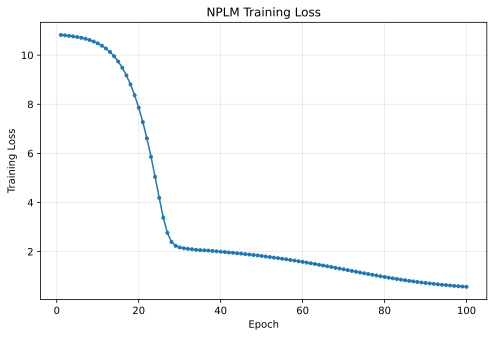

In [49]:
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

# Example tokenizer; for teaching/demo this is convenient.
# Any tokenizer is fine as long as it returns integer ids.
tokenizer = AutoTokenizer.from_pretrained("gpt2")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

text = """
the cat sat on the mat .
the dog sat on the rug .
the cat chased the dog .
the dog chased the cat .
"""

enc = tokenizer(text, add_special_tokens=False)
token_ids = enc["input_ids"]

context_size = 3
dataset = NPLMTextDataset(token_ids, context_size=context_size)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

config = NPLMConfig(
    vocab_size=tokenizer.vocab_size,
    context_size=context_size,
    embedding_dim=64,
    hidden_dim=128,
    use_direct_connections=True,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = BengioNPLM(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

num_epochs = 100
epoch_losses = []

model.train()
for epoch in tqdm(range(num_epochs)):
    total_loss = 0.0
    total_items = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        bs = input_ids.size(0)
        total_loss += loss.item() * bs
        total_items += bs

    avg_loss = total_loss / max(total_items, 1)
    epoch_losses.append(avg_loss)

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), epoch_losses, marker='o', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("NPLM Training Loss")
plt.grid(True, alpha=0.3)
plt.show()

- **Inference the next token given the prompt**

In [50]:
model.eval()
prompt = "the cat sat"
prompt_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]

# keep only last `context_size` tokens
context = prompt_ids[-context_size:]
if len(context) < context_size:
    context = [tokenizer.pad_token_id] * (context_size - len(context)) + context

print(context_size, context)
x = torch.tensor([context], dtype=torch.long).to(device)
top_probs, top_ids = model.predict_next(x, top_k=5)

for p, idx in zip(top_probs[0].tolist(), top_ids[0].tolist()):
    print(f"{tokenizer.decode([idx]).strip()!r}: {p:.4f}")

3 [1169, 3797, 3332]
'on': 0.5632
'the': 0.1958
'': 0.1066
'the': 0.0331
'chased': 0.0195


<a id=33></a>
#### 3.3 NPLM on wikitext dataset

In [51]:
from datasets import load_dataset
ds = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")
print(ds["train"])

Dataset({
    features: ['text'],
    num_rows: 36718
})


In [52]:
print(ds)

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})


In [ ]:
from datasets import load_dataset
from torch.utils.data import DataLoader
from transformers import AutoTokenizer
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

# --------------------------------------------------
# 1. Load dataset
# --------------------------------------------------
ds = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")
print(ds["train"])

# --------------------------------------------------
# 2. Tokenizer
# --------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained("gpt2")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# --------------------------------------------------
# 3. Convert the whole training split into token ids
#    We skip empty lines to reduce useless samples.
# --------------------------------------------------
train_texts = [x for x in ds["train"]["text"] if x.strip()]

# Join documents with eos token so boundaries are visible
full_text = f" {tokenizer.eos_token} ".join(train_texts)

enc = tokenizer(full_text, add_special_tokens=False)
token_ids = enc["input_ids"]

print(f"Number of training documents: {len(train_texts)}")
print(f"Number of training tokens: {len(token_ids)}")

# --------------------------------------------------
# 4. Build dataset / dataloader
# --------------------------------------------------
context_size = 3
dataset = NPLMTextDataset(token_ids, context_size=context_size)
loader = DataLoader(dataset, batch_size=128, shuffle=True)

print(f"Number of training examples: {len(dataset)}")

# --------------------------------------------------
# 5. Model config
# --------------------------------------------------
config = NPLMConfig(
    vocab_size=tokenizer.vocab_size,
    context_size=context_size,
    embedding_dim=64,
    hidden_dim=128,
    use_direct_connections=True,
)

if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
model = BengioNPLM(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

# --------------------------------------------------
# 6. Training
# --------------------------------------------------
num_epochs = 10
epoch_losses = []

model.train()
for epoch in range(num_epochs):
    total_loss = 0.0
    total_items = 0

    progress = tqdm(loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for batch in progress:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        bs = input_ids.size(0)
        total_loss += loss.item() * bs
        total_items += bs

        progress.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = total_loss / max(total_items, 1)
    epoch_losses.append(avg_loss)

# --------------------------------------------------
# 7. Plot training loss
# --------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), epoch_losses, marker="o", markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("NPLM Training Loss on WikiText-2")
plt.grid(True, alpha=0.3)
plt.show()

Dataset({
    features: ['text'],
    num_rows: 36718
})


Token indices sequence length is longer than the specified maximum sequence length for this model (2463182 > 1024). Running this sequence through the model will result in indexing errors


Number of training documents: 23767
Number of training tokens: 2463182
Number of training examples: 2463179


Epoch 1/10:  18%|██████████▏                                               | 3379/19244 [33:51<32:16,  8.19it/s, loss=5.7776]

<a id=4></a>
### 4. LSTM

- This demo code of LSTM is from Word Language Model

In [61]:
import os
import time
import math
import torch
import argparse
import torch.onnx
from io import open
import torch.nn as nn
import torch.nn.functional as F

Word-level Language Modeling using RNN and Transformer
> This example trains a multi-layer RNN (Elman, GRU, or LSTM) or Transformer on a language modeling task. By default, the training script uses the Wikitext-2 dataset, provided. The trained model can then be used by the generate script to generate new text.

```shell
python main.py --cuda --epochs 6           # Train a LSTM on Wikitext-2 with CUDA.
python main.py --cuda --epochs 6 --tied    # Train a tied LSTM on Wikitext-2 with CUDA.
python main.py --cuda --tied               # Train a tied LSTM on Wikitext-2 with CUDA for 40 epochs.
python main.py --cuda --epochs 6 --model Transformer --lr 5 # Train a Transformer model on Wikitext-2 with CUDA.
python generate.py                         # Generate samples from the default model checkpoint.
```
This example trains a multi-layer RNN (Elman, GRU, or LSTM) or Transformer on a language modeling task. By default, the training script uses the Wikitext-2 dataset, provided. The trained model can then be used by the generate script to generate new text.

```shell
python main.py --cuda --epochs 6           # Train a LSTM on Wikitext-2 with CUDA.
python main.py --cuda --epochs 6 --tied    # Train a tied LSTM on Wikitext-2 with CUDA.
python main.py --cuda --tied               # Train a tied LSTM on Wikitext-2 with CUDA for 40 epochs.
python main.py --cuda --epochs 6 --model Transformer --lr 5 # Train a Transformer model on Wikitext-2 with CUDA.
python generate.py                         # Generate samples from the default model checkpoint.
```

The model uses the nn.RNN module (and its sister modules nn.GRU and nn.LSTM) or Transformer module (nn.TransformerEncoder and nn.TransformerEncoderLayer) which will automatically use the cuDNN backend if run on CUDA with cuDNN installed.

During training, if a keyboard interrupt (Ctrl-C) is received, training is stopped and the current model is evaluated against the test dataset.

The main.py script accepts the following arguments:

optional arguments:
  -h, --help            show this help message and exit
  --data DATA           location of the data corpus
  --model MODEL         type of network (RNN_TANH, RNN_RELU, LSTM, GRU, Transformer)
  --emsize EMSIZE       size of word embeddings
  --nhid NHID           number of hidden units per layer
  --nlayers NLAYERS     number of layers
  --lr LR               initial learning rate
  --clip CLIP           gradient clipping
  --epochs EPOCHS       upper epoch limit
  --batch_size N        batch size
  --bptt BPTT           sequence length
  --dropout DROPOUT     dropout applied to layers (0 = no dropout)
  --tied                tie the word embedding and softmax weights
  --seed SEED           random seed
  --cuda                use CUDA
  --mps                 enable GPU on macOS
  --log-interval N      report interval
  --save SAVE           path to save the final model
  --onnx-export ONNX_EXPORT
                        path to export the final model in onnx format
  --nhead NHEAD         the number of heads in the encoder/decoder of the transformer model
  --dry-run             verify the code and the model

With these arguments, a variety of models can be tested. As an example, the following arguments produce slower but better models:

```shell
python main.py --cuda --emsize 650 --nhid 650 --dropout 0.5 --epochs 40
python main.py --cuda --emsize 650 --nhid 650 --dropout 0.5 --epochs 40 --tied
python main.py --cuda --emsize 1500 --nhid 1500 --dropout 0.65 --epochs 40
python main.py --cuda --emsize 1500 --nhid 1500 --dropout 0.65 --epochs 40 --tied
```

In [62]:
# say you do NOT have a GPU
%run main.py --mps --epochs 6 --data './dataset/wikitext-2'

| epoch   1 |   200/ 2983 batches | lr 20.00 | ms/batch 48.88 | loss  7.67 | ppl  2141.49
| epoch   1 |   400/ 2983 batches | lr 20.00 | ms/batch 29.66 | loss  6.88 | ppl   976.57
| epoch   1 |   600/ 2983 batches | lr 20.00 | ms/batch 29.61 | loss  6.56 | ppl   705.62
| epoch   1 |   800/ 2983 batches | lr 20.00 | ms/batch 29.40 | loss  6.37 | ppl   584.05
| epoch   1 |  1000/ 2983 batches | lr 20.00 | ms/batch 29.55 | loss  6.23 | ppl   505.37
| epoch   1 |  1200/ 2983 batches | lr 20.00 | ms/batch 29.27 | loss  6.14 | ppl   462.83
| epoch   1 |  1400/ 2983 batches | lr 20.00 | ms/batch 30.24 | loss  6.03 | ppl   415.68
| epoch   1 |  1600/ 2983 batches | lr 20.00 | ms/batch 30.32 | loss  6.03 | ppl   413.84
| epoch   1 |  1800/ 2983 batches | lr 20.00 | ms/batch 29.51 | loss  5.89 | ppl   362.72
| epoch   1 |  2000/ 2983 batches | lr 20.00 | ms/batch 28.92 | loss  5.88 | ppl   356.55
| epoch   1 |  2200/ 2983 batches | lr 20.00 | ms/batch 29.00 | loss  5.76 | ppl   318.57
| epoch   

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL model.RNNModel was not an allowed global by default. Please use `torch.serialization.add_safe_globals([model.RNNModel])` or the `torch.serialization.safe_globals([model.RNNModel])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with wei

In [67]:
# Generate samples from the default model checkpoint.
%run generate.py --data './dataset/wikitext-2' --checkpoint './model.pt' --outf 'generated.txt' --mps

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL model.RNNModel was not an allowed global by default. Please use `torch.serialization.add_safe_globals([model.RNNModel])` or the `torch.serialization.safe_globals([model.RNNModel])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn more about types accepted by default with wei

In [70]:
%run cat generated.txt

Exception: File `'cat'` not found.